<a href="https://colab.research.google.com/github/CarlosPossi/Engenharia_De_Software/blob/main/Exercicios_da_Aula_6_%7C_Eng_Software_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🎯 Exercício Prático — Miro + Python**
***Tema:*** Cadastro e Aprovação de Usuário num App
<br>
<br>
***Cenário:*** Um usuário tenta se cadastrar num aplicativo. O sistema valida o e-mail, verifica se já existe conta, envia confirmação e libera o acesso.

###***Parte 1 — Miro***
Monte o Diagrama de Atividades com **Swimlanes** para:
<br>
<br>
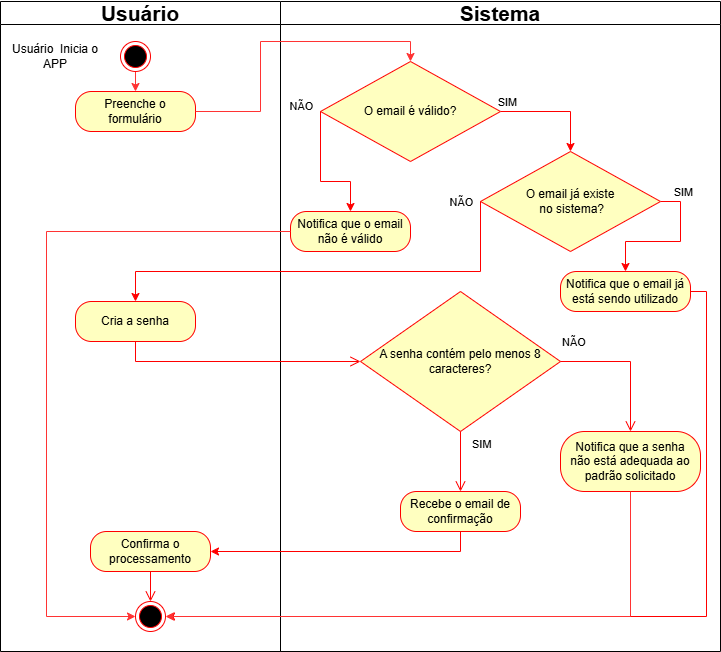

**Comentário sobre o que o diagrama representa e as decisões de modelagem:**
<br>
O diagrama representa um fluxo de cadastro de usuário em um sistema, destacando a interação entre o usuário e o sistema durante a validação de e-mail e senha.
A modelagem utiliza decisões condicionais para garantir integridade dos dados, como verificação de formato de e-mail, existência no sistema e critérios mínimos de senha.
A separação em raias (Usuário e Sistema) evidencia responsabilidades, deixando claro o que é ação do usuário e o que é processamento automatizado.

### ***Parte 2 — Python no Colab/VS Code***
Implemente o fluxo do diagrama em Python:

In [ ]:
!pip install email-validator

from email_validator import validate_email, EmailNotValidError
import dns.resolver

In [ ]:
def cadastro_usuario(email: str, senha: str, email_ja_existe: bool, confirmou_email: bool) -> str:

  def dominio_valido(email):
    dominio = email.split('@')[-1]
    try:
      dns.resolver.resolve(dominio, 'MX')
      return True
    except:
      return False

  if email_ja_existe:
    return "⚠️ Email já cadastrado no sistema"

  try:
    validate_email(email)
  except EmailNotValidError:
    return "❌ Email inválido"

  if not dominio_valido(email):
    return "❌ Dominio de email inválido"

  if not senha or len(senha.strip()) < 8:
    return "❌ Senha inválida, deve conter no mínimo 8 caracteres"

  if not confirmou_email:
    return "⏳Estamos aguardando a confirmação do seu email"

  return "✅ Cadastro realizado com sucesso !!!"

  pass

# Testes (não apague!)
print("👤 Realize seu cadastro: ")
print("📧 Email: joao@email.com")
print("🔒 Senha: senha123\n")
print(cadastro_usuario("joao@email.com", "senha123", False, True), "\n")

print("👤 Realize seu cadastro: ")
print("📧 Email: email-invalido")
print("🔒 Senha: senha123\n")
print(cadastro_usuario("email-invalido", "senha123", False, True), "\n")

print("👤 Realize seu cadastro: ")
print("📧 Email: joao@email.com")
print("🔒 Senha: senha123\n")
print(cadastro_usuario("joao@email.com", "senha123", True, True), "\n")

print("👤 Realize seu cadastro: ")
print("📧 Email: carlos@email.com")
print("🔒 Senha: 124 \n")
print(cadastro_usuario("carlos@email.com", "124", False, True), "\n")

print("👤 Realize seu cadastro: ")
print("📧 Email: camila@email.com")
print("🔒 Senha: senha123\n")
print(cadastro_usuario("camila@email.com", "senha123", False, False), "\n")

👤 Realize seu cadastro: 
📧 Email: joao@email.com
🔒 Senha: senha123

✅ Cadastro realizado com sucesso !!! 

👤 Realize seu cadastro: 
📧 Email: email-invalido
🔒 Senha: senha123

❌ Email inválido 

👤 Realize seu cadastro: 
📧 Email: joao@email.com
🔒 Senha: senha123

⚠️ Email já cadastrado no sistema 

👤 Realize seu cadastro: 
📧 Email: carlos@email.com
🔒 Senha: 124 

❌ Senha inválida, deve conter no mínimo 8 caracteres 

👤 Realize seu cadastro: 
📧 Email: camila@email.com
🔒 Senha: senha123

⏳Estamos aguardando a confirmação do seu email 



**Comentário sobre o que o código implementa e o que foi aprendido:**
<br>
O código implementa um fluxo de validação de cadastro de usuário, aplicando regras como verificação de e-mail (formato e domínio), checagem de duplicidade, validação de senha e confirmação de e-mail.
A lógica segue uma sequência de decisões condicionais que simula o fluxo de um diagrama de cadastro com validações sucessivas e mensagens de retorno.
O principal aprendizado é como estruturar regras de negócio em etapas claras e encadeadas, além da importância de validar entradas para garantir consistência e segurança no sistema.

**Comentário sobre o output exibido:**
<br>
O output demonstra a execução do fluxo de cadastro de usuários com diferentes cenários de validação, incluindo sucesso, e-mails inválidos, duplicidade de cadastro, senha fraca e pendência de confirmação de e-mail.
Ele evidencia que o sistema aplica corretamente regras de negócio em sequência, retornando mensagens específicas para cada tipo de falha.
Isso mostra a importância de validações bem definidas para garantir consistência, segurança e controle no processo de cadastro.
